# 05 · Class-Imbalance Experiments (Ablation)

**Owner:** Riya (Model Lead)

Same architecture, optimiser (Adam, lr 1e-3, weight decay 1e-4), early stopping and seed (42) — **only the imbalance strategy changes**:

| # | Strategy | What changes |
|---|---|---|
| 1 | Plain BCE | nothing (`nn.BCELoss()`) |
| 2 | Class-weighted BCE | `nn.BCEWithLogitsLoss(pos_weight = N_neg / N_pos)` — each churner's loss ×≈2.77 |
| 3 | Random oversampling | `RandomOverSampler` duplicates churners **in X_train only** until 50/50; val/test untouched |
| 4 | Focal loss (from scratch) | $FL(p_t) = -\alpha_t (1-p_t)^\gamma \log p_t$, γ = 2, α = 0.75 — `src/focal_loss.py` |

All comparisons use the **validation** split. **Selection rule (fixed before looking at results):** the winner is the strategy with the highest *mean validation PR-AUC over seeds 42–46*; we then deploy its seed-42 model. PR-AUC is threshold-free and focuses on how well churners are ranked — the operating threshold is chosen separately by business cost (notebook 06).

In [1]:
# ── Environment setup: works on Google Colab (Drive) AND locally (VS Code / Jupyter) ──
import os, sys

try:
    from google.colab import drive  # only importable inside a Colab runtime
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/telco-churn-dashboard'
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    _cwd = os.path.abspath(os.getcwd())
    PROJECT_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebooks' else _cwd

os.makedirs(PROJECT_ROOT, exist_ok=True)
os.chdir(PROJECT_ROOT)                      # every relative path is now project-relative
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)        # lets us `import src...`
print('Project root:', PROJECT_ROOT, '| running on Colab:', IN_COLAB)

Project root: /Users/friday/Desktop/nndl/telco-churn-dashboard | running on Colab: False


In [2]:
# Colab already ships torch, numpy, pandas, scikit-learn, matplotlib and seaborn.
# Install the extras once per Colab session (skipped automatically when running locally).
if IN_COLAB:
    %pip install -q imbalanced-learn shap fastapi uvicorn jinja2 python-multipart joblib

In [3]:
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from src import config
from src import plotting as P
from src.calibration import reliability_summary
from src.data_preprocessing import load_splits
from src.focal_loss import FocalLoss
from src.metrics import classification_metrics, find_f1_optimal_threshold, metrics_table, to_markdown_table
from src.model import ChurnMLP, predict_proba
from src.training import IMBALANCE_STRATEGIES, prepare_imbalance_strategy, train_mlp

P.apply_style()
device = config.get_device()
splits = load_splits()
X_train, y_train, X_val, y_val = splits.X_train, splits.y_train, splits.X_val, splits.y_val
D_in = X_train.shape[1]
n_pos, n_neg = int(y_train.sum()), int((y_train == 0).sum())
print(f'train churners {n_pos:,} | non-churners {n_neg:,} | pos_weight = N_neg/N_pos = {n_neg / n_pos:.3f}')

train churners 1,121 | non-churners 3,104 | pos_weight = N_neg/N_pos = 2.769


## 1 · Focal loss — sanity checks and intuition
With γ = 0 and α = 0.5 focal loss must equal exactly ½·BCE. The plot shows how the modulating factor $(1-p_t)^\gamma$ shrinks the loss of well-classified examples (large $p_t$).

FocalLoss(γ=0, α=0.5) = 0.398913   0.5 × BCE = 0.398913


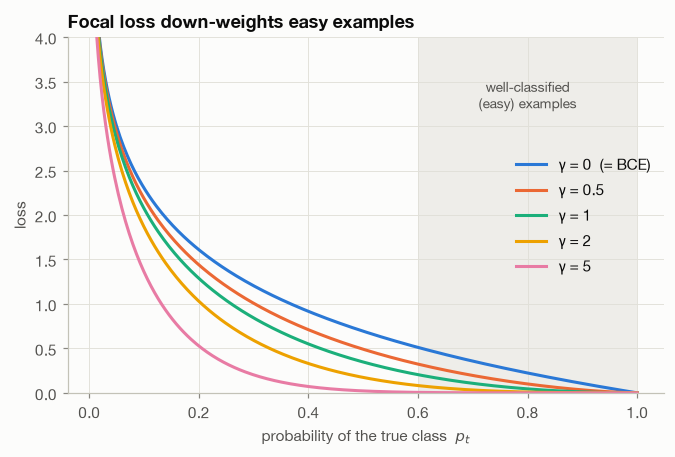

Easy example p_t=0.95: BCE 0.0513 vs focal(γ=2) 0.000128  (400× smaller)


In [4]:
logits = torch.randn(1000)
targets = (torch.rand(1000) > 0.7).float()
fl = FocalLoss(alpha=0.5, gamma=0.0)(logits, targets)
bce = F.binary_cross_entropy_with_logits(logits, targets)
print(f'FocalLoss(γ=0, α=0.5) = {fl:.6f}   0.5 × BCE = {0.5 * bce:.6f}')
assert torch.allclose(fl, 0.5 * bce, atol=1e-6)

p_t = np.linspace(0.01, 1, 300)
fig, ax = plt.subplots(figsize=(7, 4.2))
for color, gamma in zip(P.SERIES, [0, 0.5, 1, 2, 5]):
    ax.plot(p_t, -(1 - p_t) ** gamma * np.log(p_t), color=color, label=f'γ = {gamma}' + ('  (= BCE)' if gamma == 0 else ''))
ax.axvspan(0.6, 1.0, color=P.GRID, alpha=0.5, linewidth=0)
ax.text(0.8, 3.2, 'well-classified\n(easy) examples', ha='center', color=P.INK_SECONDARY, fontsize=9)
ax.set(xlabel='probability of the true class  $p_t$', ylabel='loss', ylim=(0, 4),
       title='Focal loss down-weights easy examples')
ax.legend()
P.save_figure(fig, config.PLOTS_DIR / 'focal_loss_curves.png')
plt.show()
print(f'Easy example p_t=0.95: BCE {-np.log(0.95):.4f} vs focal(γ=2) {-(0.05**2) * np.log(0.95):.6f}  (400× smaller)')

## 2 · Run the four experiments (seed 42)

In [5]:
results, histories, val_probs = {}, {}, {}
for name, label in IMBALANCE_STRATEGIES.items():
    config.set_seed(config.SEED)                                   # identical init + batch order
    setup = prepare_imbalance_strategy(name, X_train, y_train, seed=config.SEED)
    net = ChurnMLP(D_in)
    net, hist = train_mlp(net, setup.X_fit, setup.y_fit, X_val, y_val, setup.criterion,
                          criterion_on_logits=setup.on_logits, seed=config.SEED, device=device,
                          verbose=False, checkpoint_path=config.ABLATION_DIR / f'{name}.pth')
    prob = predict_proba(net, X_val, device=device)
    metrics = classification_metrics(y_val, prob, threshold=0.5)
    f1_thr, f1_best = find_f1_optimal_threshold(y_val, prob)
    results[name] = {**metrics, 'best_f1': f1_best, 'best_f1_threshold': f1_thr,
                     'brier': reliability_summary(y_val, prob)['brier'], 'mean_prob': float(prob.mean()),
                     'best_epoch': hist.best_epoch, 'epochs_run': hist.epochs_run, 'train_rows': len(setup.y_fit)}
    histories[name], val_probs[name] = hist, prob
    print(f'{label:30s} rows {len(setup.y_fit):5,} | best epoch {hist.best_epoch:3d}/{hist.epochs_run:3d} '
          f'| PR-AUC {metrics["pr_auc"]:.4f} | F1@0.5 {metrics["f1"]:.4f} | recall@0.5 {metrics["recall"]:.4f}')

1. Plain BCE                   rows 4,225 | best epoch  21/ 31 | PR-AUC 0.6311 | F1@0.5 0.5971 | recall@0.5 0.5588


2. Weighted BCE                rows 4,225 | best epoch   6/ 16 | PR-AUC 0.6353 | F1@0.5 0.6109 | recall@0.5 0.7914


3. Random Oversampling         rows 6,208 | best epoch  10/ 20 | PR-AUC 0.6261 | F1@0.5 0.6189 | recall@0.5 0.7513


4. Focal Loss (From Scratch)   rows 4,225 | best epoch   6/ 16 | PR-AUC 0.6324 | F1@0.5 0.6083 | recall@0.5 0.8262


## 3 · Ablation results table (validation, seed 42, threshold 0.5)

In [6]:
labels = {IMBALANCE_STRATEGIES[k]: v for k, v in results.items()}
ablation_table = metrics_table(labels)
ablation_table.to_csv(config.RESULTS_DIR / 'ablation_val.csv')
print(to_markdown_table(ablation_table))
ablation_table

| Model | Precision | Recall | F1 (Churn) | PR-AUC | ROC-AUC |
|---|---|---|---|---|---|
| 1. Plain BCE | 0.6411 | 0.5588 | 0.5971 | 0.6311 | 0.8317 |
| 2. Weighted BCE | 0.4975 | 0.7914 | 0.6109 | 0.6353 | 0.8340 |
| 3. Random Oversampling | 0.5262 | 0.7513 | 0.6189 | 0.6261 | 0.8309 |
| 4. Focal Loss (From Scratch) | 0.4813 | 0.8262 | 0.6083 | 0.6324 | 0.8332 |


,Precision,Recall,F1 (Churn),PR-AUC,ROC-AUC
Model,,,,,
1. Plain BCE,0.6411,0.5588,0.5971,0.6311,0.8317
2. Weighted BCE,0.4975,0.7914,0.6109,0.6353,0.8340
3. Random Oversampling,0.5262,0.7513,0.6189,0.6261,0.8309
4. Focal Loss (From Scratch),0.4813,0.8262,0.6083,0.6324,0.8332


In [7]:
extra = pd.DataFrame(results).T[['best_f1', 'best_f1_threshold', 'mean_prob', 'brier', 'best_epoch', 'train_rows']]
extra.index = [IMBALANCE_STRATEGIES[k] for k in extra.index]
extra.columns = ['F1 at best val threshold', 'that threshold', 'mean predicted p (true rate 0.265)',
                 'Brier score', 'best epoch', 'training rows']
extra.to_csv(config.RESULTS_DIR / 'ablation_val_extra.csv')
extra.astype(float).round(4)

,F1 at best val threshold,that threshold,mean predicted p (true rate 0.265),Brier score,best epoch,training rows
1. Plain BCE,0.6185,0.33,0.2738,0.1410,21.0,4225.0
2. Weighted BCE,0.6281,0.64,0.4322,0.1751,6.0,4225.0
3. Random Oversampling,0.6241,0.48,0.3976,0.1646,10.0,6208.0
4. Focal Loss (From Scratch),0.6242,0.58,0.4683,0.1936,6.0,4225.0


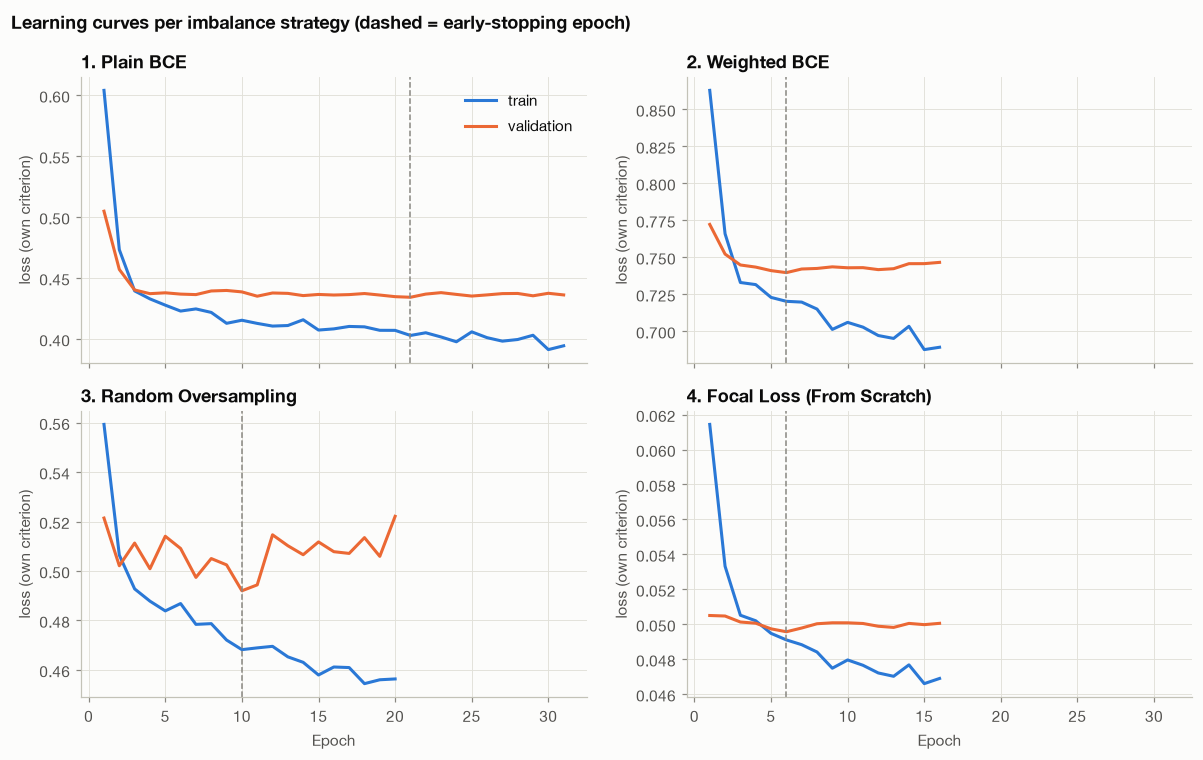

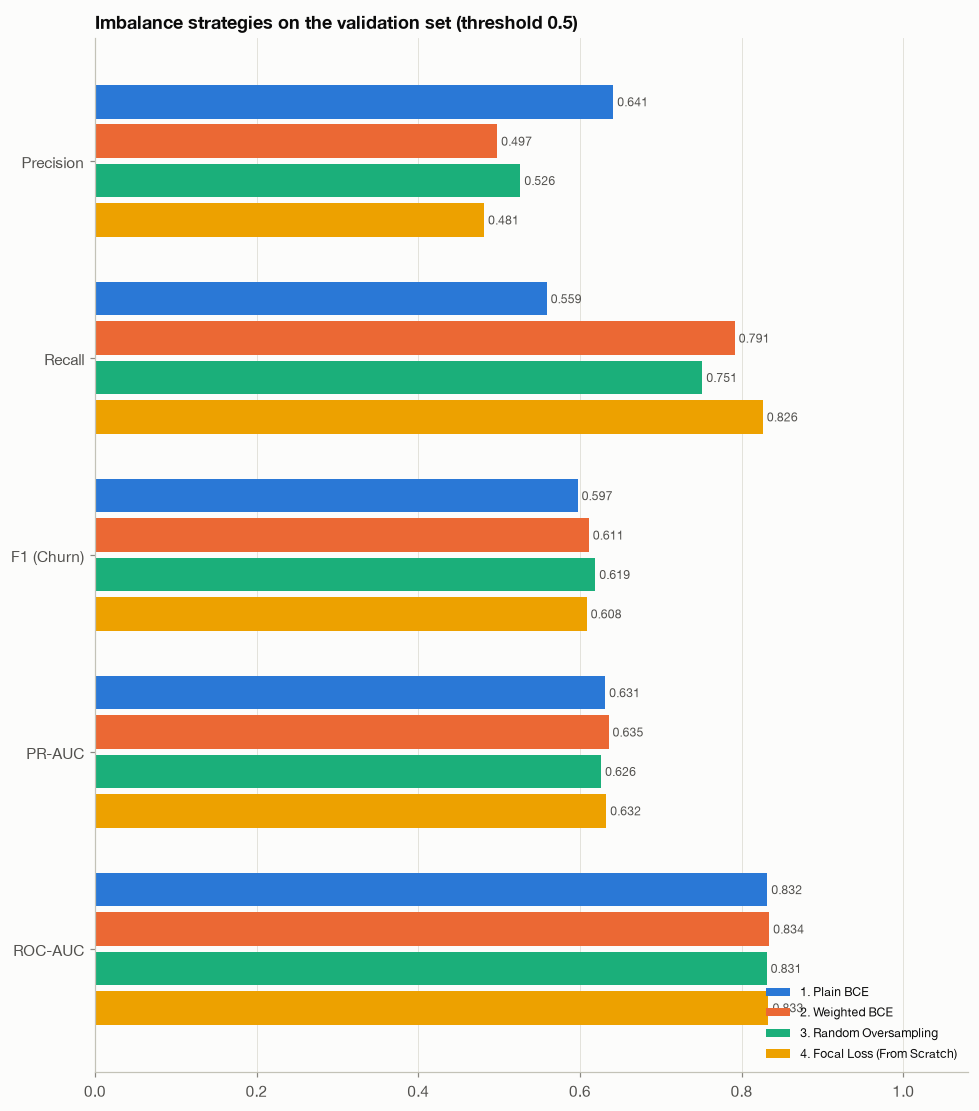

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, (name, hist) in zip(axes.ravel(), histories.items()):
    ep = np.arange(1, len(hist.train_loss) + 1)
    ax.plot(ep, hist.train_loss, color=P.BLUE, label='train')
    ax.plot(ep, hist.val_loss, color=P.ORANGE, label='validation')
    ax.axvline(hist.best_epoch, color=P.MUTED, linestyle='--', linewidth=1)
    ax.set_title(IMBALANCE_STRATEGIES[name])
    ax.set_ylabel('loss (own criterion)')
axes[0, 0].legend()
for ax in axes[1]:
    ax.set_xlabel('Epoch')
fig.suptitle('Learning curves per imbalance strategy (dashed = early-stopping epoch)', x=0.01, ha='left',
             fontweight='bold')
fig.tight_layout()
P.save_figure(fig, config.PLOTS_DIR / 'ablation_learning_curves.png')
plt.show()

fig = P.plot_metric_bars(ablation_table, list(ablation_table.columns),
                         'Imbalance strategies on the validation set (threshold 0.5)')
P.save_figure(fig, config.PLOTS_DIR / 'ablation_metrics.png')
plt.show()

## 4 · Robustness — are the differences real? (seeds 42–46)
The four PR-AUCs are within about 0.01 of each other, which is the size of run-to-run noise. We repeat every strategy with five seeds (different initial weights, batch order and oversampling draw) and compare the means.

In [9]:
SEEDS = [42, 43, 44, 45, 46]
rows = []
for name in IMBALANCE_STRATEGIES:
    for seed in SEEDS:
        config.set_seed(seed)
        setup = prepare_imbalance_strategy(name, X_train, y_train, seed=seed)
        net = ChurnMLP(D_in)
        net, hist = train_mlp(net, setup.X_fit, setup.y_fit, X_val, y_val, setup.criterion,
                              criterion_on_logits=setup.on_logits, seed=seed, device=device, verbose=False)
        m = classification_metrics(y_val, predict_proba(net, X_val, device=device))
        rows.append({'strategy': name, 'seed': seed, 'pr_auc': m['pr_auc'], 'roc_auc': m['roc_auc'],
                     'f1@0.5': m['f1'], 'best_epoch': hist.best_epoch})
seed_runs = pd.DataFrame(rows)
seed_runs.to_csv(config.RESULTS_DIR / 'ablation_seeds.csv', index=False)
seed_summary = seed_runs.groupby('strategy').agg(
    pr_auc_mean=('pr_auc', 'mean'), pr_auc_std=('pr_auc', 'std'),
    roc_auc_mean=('roc_auc', 'mean'), f1_mean=('f1@0.5', 'mean')).reindex(list(IMBALANCE_STRATEGIES))
seed_summary.index = [IMBALANCE_STRATEGIES[k] for k in seed_summary.index]
seed_summary.round(4)

,pr_auc_mean,pr_auc_std,roc_auc_mean,f1_mean
1. Plain BCE,0.6351,0.0039,0.8326,0.6038
2. Weighted BCE,0.6381,0.0025,0.8346,0.6143
3. Random Oversampling,0.6309,0.0063,0.8315,0.6158
4. Focal Loss (From Scratch),0.6358,0.0034,0.8333,0.6031


## 5 · Select the winner and save it as `best_model.pth`

In [10]:
means = seed_runs.groupby('strategy')['pr_auc'].mean()
winner = str(means.idxmax())
print(f'Winner: {IMBALANCE_STRATEGIES[winner]}  (mean val PR-AUC {means[winner]:.4f} over seeds {SEEDS})')
print(f'Seed-42 ranking agrees? {max(results, key=lambda k: results[k]["pr_auc"]) == winner}')

shutil.copyfile(config.ABLATION_DIR / f'{winner}.pth', config.BEST_MODEL_PATH)
setup = prepare_imbalance_strategy(winner, X_train, y_train, seed=config.SEED)
cfg = config.update_model_config({'imbalance_strategy': {
    'name': winner,
    'label': IMBALANCE_STRATEGIES[winner],
    'selection_rule': f'highest mean validation PR-AUC over seeds {SEEDS}; deployed model = seed 42',
    'val_pr_auc_mean': float(means[winner]),
    'val_pr_auc_std': float(seed_runs.loc[seed_runs.strategy == winner, 'pr_auc'].std()),
    'val_metrics_seed42': {k: results[winner][k] for k in ['precision', 'recall', 'f1', 'pr_auc', 'roc_auc']},
    'details': setup.details,
}})
print('best_model.pth <-', f'models/ablation/{winner}.pth')

Winner: 2. Weighted BCE  (mean val PR-AUC 0.6381 over seeds [42, 43, 44, 45, 46])
Seed-42 ranking agrees? True
best_model.pth <- models/ablation/weighted_bce.pth


### Justification of the winning strategy
* **Class-weighted BCE** has the highest validation PR-AUC both at seed 42 and on average over five seeds, with the smallest seed-to-seed spread — the most reliable ranking of churners.
* All four strategies land within ≈0.01 PR-AUC of each other. The main effect of imbalance handling is to **move the operating point**: at threshold 0.5, recall jumps from ≈0.56 (plain BCE) to ≈0.79 (weighted) and ≈0.83 (focal) — at the cost of precision. Because the threshold is re-optimised on business cost in notebook 06, the quantity that really matters for model choice is ranking quality (PR-AUC), which is why it is our selection metric.
* Weighted BCE, oversampling and focal loss all **inflate the predicted probabilities** (mean predicted p > the true 26.5 % rate; worse Brier score). Notebook 06 fixes this with Platt calibration so the dashboard's probabilities and expected-savings figures are trustworthy.
* Oversampling was weakest and has the highest seed-to-seed variance: exact duplicates of churner rows add no new information and make it easier for the network to over-fit those specific customers.